In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
import warnings
from py_code import XGB_test_model
from py_code import CNN1D_test_model
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch
from pathlib import Path

In [2]:
txt_dir = Path("output_files_ML/HAWCSim_array/test_gammas/100300TeV_030deg_4FF_180R175h_Black/")

y_test = []
p_test = []

for txt_file in txt_dir.glob("*.txt"):
    name = txt_file.stem
    txt_file_name = str(txt_file)
    rc, pr, y_te, p_te = np.loadtxt(txt_file_name).T
    p_test.append(p_te)
    y_test.append(y_te)

p_test = np.concatenate(p_test)
y_test = np.concatenate(y_test)

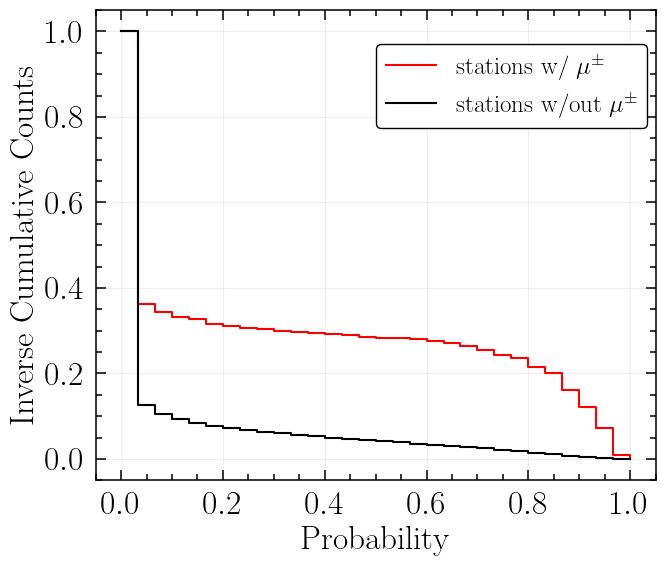

In [3]:
bins = 30

x_s, icdf_s = XGB_test_model.binned_inv_cdf(p_test[y_test == 1], bins=bins)
x_b, icdf_b = XGB_test_model.binned_inv_cdf(p_test[y_test == 0], bins=bins)

u = np.linspace(0, 1, len(icdf_s), endpoint=True)
du = u[1] - u[0]

pdf_s = du / np.diff(icdf_s, append=icdf_s[-1])
pdf_b = du / np.diff(icdf_b, append=icdf_b[-1])

pdf_s = np.clip(pdf_s, 0, np.inf)
pdf_b = np.clip(pdf_b, 0, np.inf)

plt.figure(figsize=(7, 6))

plt.step(u, icdf_s, where="post", lw=1.5, color="red", label=r"stations w/ $\mu^{\pm}$")
plt.step(u, icdf_b, where="post", lw=1.5, color="black", label=r"stations w/out $\mu^{\pm}$")

plt.xlabel("Probability", fontsize = 24)
plt.ylabel("Inverse Cumulative Counts", fontsize = 24)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 24)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 24)
plt.xlim(-0.05, 1.05)

plt.legend(frameon=True, fontsize=18, loc=(0.5,0.75), facecolor="white", framealpha=1, edgecolor = "black")
plt.grid(True, alpha=0.2)
plt.tight_layout()
path = "pictures/HAWCSim_array/inverse_cdf/"
plt.savefig(path + "inv_cum_1bkg13smu.pdf", dpi = 300, bbox_inches = 'tight')
plt.show()

Number of true muons stations =  600
Number of non-muons stations =  77936


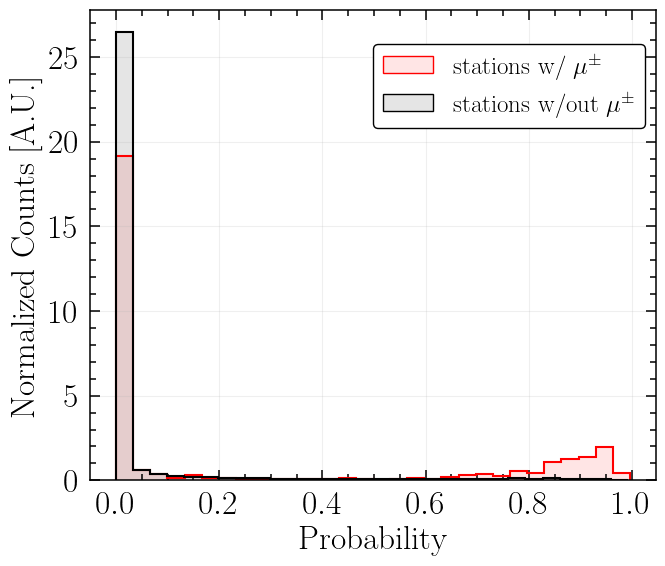

In [4]:
bins = 30
plt.figure(figsize=(7, 6))

plt.hist(p_test[y_test == 1],bins=bins, density=True,histtype="stepfilled", color="red", alpha=0.1)
plt.hist(p_test[y_test == 1],bins=bins, density=True,histtype="step", color="red", lw=1.5)
plt.hist(p_test[y_test == 0],bins=bins, density=True,histtype="stepfilled", color="black", alpha=0.1)
plt.hist(p_test[y_test == 0],bins=bins, density=True,histtype="step", color="black", lw=1.5)

print("Number of true muons stations = ", len(y_test[y_test == 1]))
print("Number of non-muons stations = ", len(y_test[y_test == 0]))
 
handles = [
    Patch(facecolor=(1,0,0,0.1), edgecolor=(1,0,0,1), linewidth=1, label=r"stations w/ $\mu^{\pm}$"),
    Patch(facecolor=(0,0,0,0.1), edgecolor=(0,0,0,1), linewidth=1, label=r"stations w/out $\mu^{\pm}$"),]

plt.xlabel("Probability", fontsize = 24)
plt.ylabel("Normalized Counts [A.U.]", fontsize = 24)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize = 24)
plt.yticks(fontsize = 24)

plt.legend(handles = handles, frameon=True, fontsize=18, facecolor="white", edgecolor = "black", framealpha=1, loc=(0.5,0.75))
plt.grid(True, alpha=0.2)
plt.tight_layout()
path = "pictures/HAWCSim_array/probability_dist/"
plt.savefig(path + "prob_dist_1bkg13smu.pdf", dpi = 300, bbox_inches = 'tight')
plt.show()

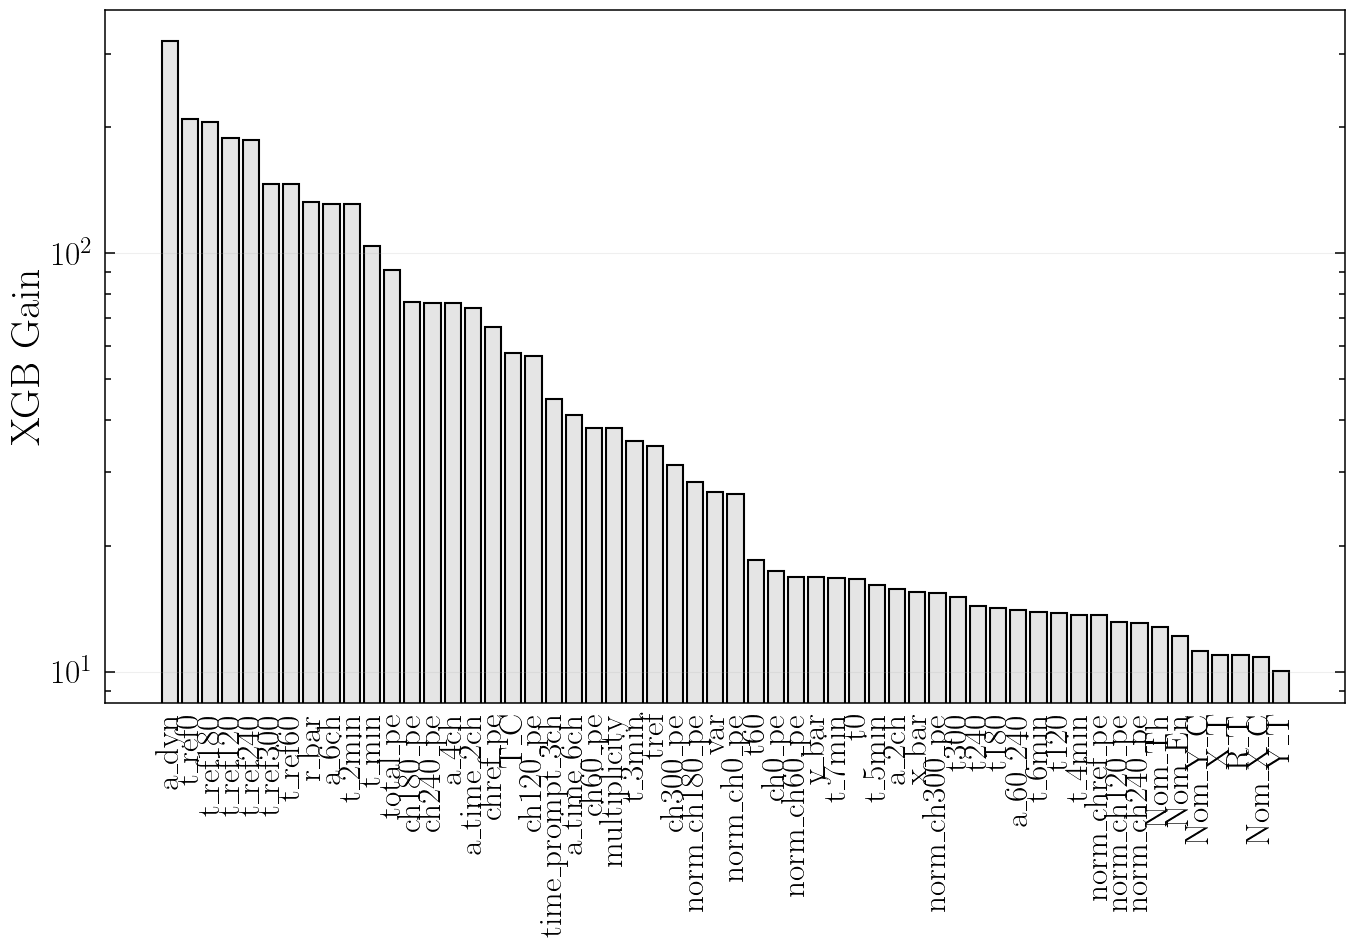

In [5]:
feat_imp_save_path = ["models_ML/HAWCSim_array/100300TeV_030deg_4FF_180R175h_Black/"]
label =["100300TeV_030deg_4FF_180R175h_Black_1bkg13smu_mPMT"]


def load_feat(path):
    fts, vals = [], []
    with open(path) as f:
        for l in f:
            if l.strip():
                n, v = l.strip().split()
                fts.append(n)
                vals.append(float(v))
    return np.array(fts), np.array(vals)


imp_feat, imp_vals = load_feat(feat_imp_save_path[0] + "xgb_feature_importance_" + label[0] + ".txt")


idx = np.argsort(imp_vals)

plt.figure(figsize=(16, 9))

plt.bar(imp_feat[idx], imp_vals[idx], color="black", alpha=0.1)
plt.bar(imp_feat[idx], imp_vals[idx], facecolor='none', edgecolor='black', linewidth=1.5)

plt.ylabel("XGB Gain", fontsize=30)

plt.tick_params(axis='x', which='both', bottom=False, top=False, left=False, right=False)

plt.xticks(rotation = 90, fontsize = 24)
plt.yticks(fontsize = 24)

plt.yscale("log")
plt.gca().invert_xaxis()  

plt.grid(True, axis='y', alpha=0.2)

path = "pictures/HAWCSim_array/features_gain/"
plt.savefig(path + "feat_gain_1bkg13smu.pdf", dpi=300, bbox_inches='tight')


plt.show()